In [80]:
pip install deap

Note: you may need to restart the kernel to use updated packages.


In [81]:
import random
import math
import numpy as np
from deap import base
from deap import creator
from deap import tools
from deap import algorithms
import matplotlib.pyplot as plt

In [82]:
# ✅ Un solo objetivo, maximización
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

In [83]:
creator.create("Individual", list, fitness=creator.FitnessMax)

In [84]:
toolbox = base.Toolbox()

In [85]:
toolbox.register("attr_uniform", random.uniform, -100,100)

In [86]:
toolbox.register("Individual", tools.initRepeat, creator.Individual, toolbox.attr_uniform,2)

In [87]:
toolbox.register("Population", tools.initRepeat, list, toolbox.Individual, 10)

In [88]:
def funcion_objetivo(x):
    for i in range(len(x)):
        if x[i] > 100 or x[i] < -100:
            return -1,
    res = math.sqrt(x[0]**2 + x[1]**2)
    return res,

In [89]:
toolbox.register("evaluate", funcion_objetivo)

In [90]:
toolbox.register("mate", tools.cxOnePoint)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=5, indpb=0.1)
toolbox.register("select",tools.selTournament, tournsize=3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


gen	nevals	avg    	std   	min    	max    
0  	10    	81.3622	28.287	31.2954	116.497
1  	2     	108.322	14.1648	71.337 	126.071
2  	7     	116.868	9.20852	98.8946	136.779
3  	4     	121.084	8.49836	112.226	136.779
4  	7     	125.454	8.40708	116.497	136.779
5  	4     	135.519	3.19937	126.071	136.779
6  	5     	136.779	0      	136.779	136.779
7  	5     	136.779	0      	136.779	136.779
8  	10    	136.779	0      	136.779	136.779
9  	4     	136.358	1.26178	132.573	136.779
10 	6     	136.779	0      	136.779	136.779
11 	6     	136.779	0      	136.779	136.779
12 	7     	136.779	0      	136.779	136.779
13 	7     	136.779	0      	136.779	136.779
14 	8     	122.639	41.2271	-1     	136.779
15 	6     	136.779	0      	136.779	136.779
16 	5     	136.779	0      	136.779	136.779
17 	6     	136.779	0      	136.779	136.779
18 	6     	136.779	0      	136.779	136.779
19 	6     	136.452	0.980645	133.51 	136.779
20 	4     	136.779	0       	136.779	136.779
Mejor fitness: 136.778896
Mejor individuo [-94.6928060

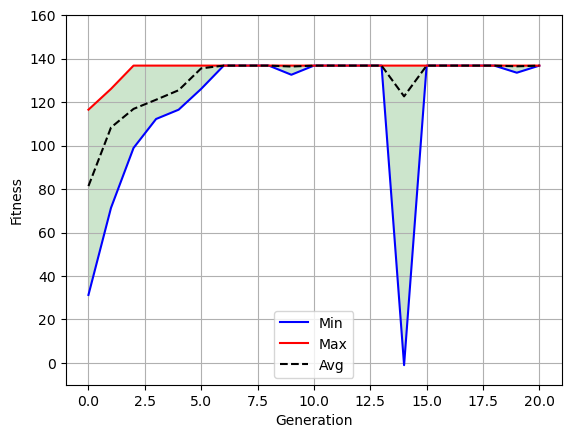

In [92]:
def main():
    random.seed(42) #Semilla que genera números aleatorios
    CXPB, MUTPB, NGEN = 0.5,0.2,20 #Probabilidades de cruza, muta y de num de generaciones
    pop = toolbox.Population() #generación de la poblacion inicial
    hof = tools.HallOfFame(1) # almacena el mejor individuo encontrado en todas las generaciones
    stats = tools.Statistics(lambda ind: ind.fitness.values) #genera las stats de poblacion sobre el fitness
    stats.register("avg",np.mean) #calcular la media
    stats.register("std",np.std) #desviación estándar típica
    stats.register("min",np.min) #valor min de la generacion
    stats.register("max",np.max) #valor max de la generacion
    logbook = tools.Logbook()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=CXPB, mutpb=MUTPB, ngen=NGEN, stats=stats, halloffame=hof, verbose=True)
    return hof, logbook

if __name__ == "__main__":
    best, log = main()
    print("Mejor fitness: %f" %best[0].fitness.values)
    print("Mejor individuo %s" %best[0])
    plot_evolucion(log)

In [93]:
def plot_evolucion(log):
    gen = np.array(log.select("gen"))
    fit_mins = np.array(log.select("min"), dtype=float)
    fit_maxs = np.array(log.select("max"), dtype=float)
    fit_ave = np.array(log.select("avg"), dtype=float)

    fig, ax1 = plt.subplots()
    ax1.plot(gen, fit_mins, "b")
    ax1.plot(gen, fit_maxs, "r")
    ax1.plot(gen, fit_ave, "--k")
    where_mask = fit_maxs >= fit_mins
    ax1.fill_between(gen,fit_mins,fit_maxs,where=where_mask, facecolor="g", alpha = 0.2)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Fitness")
    ax1.set_ylim([-10,160])
    ax1.legend(["Min","Max","Avg"], loc="lower center")
    plt.grid(True)
    plt.savefig("Convergencia.eps",dpi = 300)